# Test 8.3: MNIST (Real Structured Data)

**Гипотеза:** Свойство zero dead neurons у V4 сохраняется на реальных структурированных данных.

**Зачем:**
- Все предыдущие тесты — синтетические хаотические системы.
- MNIST — реальные данные, 28x28, 10 классов, intrinsic dim ~10-20.
- Данные структурированные (не хаотические) — sin-компонента может мешать.
- Это стандартный бенчмарк для autoencoder'ов.

**План:**
- MNIST: 60K train, 10K test, 28x28
- V4 (latent=128, K=32) vs TopK+ReLU (K=32) vs Dense_ReLU_128
- N=5 прогонов, Welch t-test
- Дополнительно: визуализация реконструкций по классам

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy import stats
import json
from datetime import datetime

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
@tf.function
def chaos_activation(x):
    return tf.sin(8.0 * x) + 0.5 * tf.tanh(4.0 * x)


class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def build_ksparse_chaos_ae(image_size=(28, 28), latent_dim=128, k_active=32):
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256)(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, name='latent_pre')(x)
    x = layers.Activation(chaos_activation)(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def build_topk_relu_ae(image_size=(28, 28), latent_dim=128, k_active=32):
    input_img = keras.Input(shape=(*image_size, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(latent_dim, activation='relu', name='latent_pre')(x)
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(256, activation='relu')(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(np.prod(image_size), activation='sigmoid')(x)
    decoded = layers.Reshape((*image_size, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def build_dense_relu_ae(image_size=(28, 28), latent_dim=128):
    h, w = image_size
    input_img = keras.Input(shape=(h, w, 1))
    x = layers.Flatten()(input_img)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(128, activation='relu')(latent)
    x = layers.Dense(256, activation='relu')(x)
    decoded = layers.Dense(h * w, activation='sigmoid')(x)
    decoded = layers.Reshape((h, w, 1))(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    return autoencoder, encoder


def analyze_latent(encoder, images, threshold=1e-6):
    latents = encoder.predict(images, verbose=0)
    variance_per_dim = np.var(latents, axis=0)
    dead_mask = np.all(np.abs(latents) < threshold, axis=0)
    zero_mask = np.abs(latents) < threshold
    return {
        'mean_variance': float(np.mean(variance_per_dim)),
        'dead_neurons': int(np.sum(dead_mask)),
        'total_neurons': latents.shape[1],
        'sparsity': float(np.mean(zero_mask)),
    }


print("Core components ready.")

Core components ready.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MNIST train: (60000, 28, 28, 1), test: (10000, 28, 28, 1)
Pixel range: [0.0, 1.0]
Mean pixel: 0.131 (sparse — mostly black)


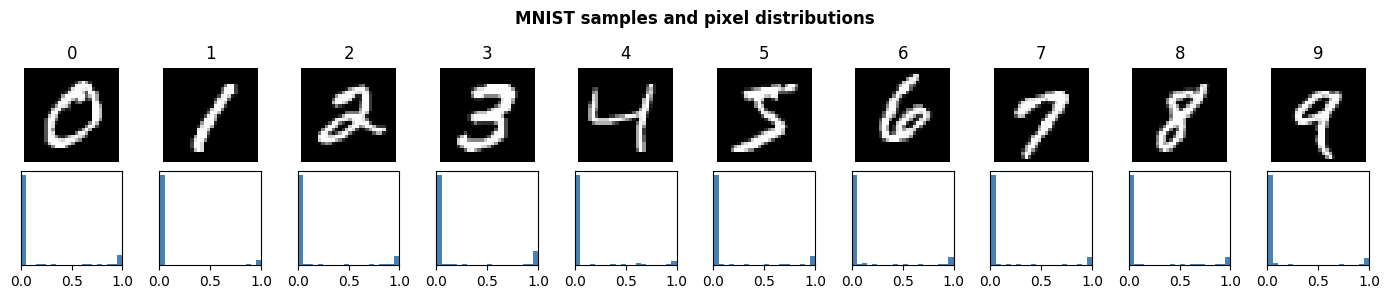

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0, 1] and add channel dim
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print(f"MNIST train: {x_train.shape}, test: {x_test.shape}")
print(f"Pixel range: [{x_train.min():.1f}, {x_train.max():.1f}]")
print(f"Mean pixel: {x_train.mean():.3f} (sparse — mostly black)")

# Show samples
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    axes[0, i].imshow(x_train[idx, :, :, 0], cmap='gray')
    axes[0, i].set_title(str(i))
    axes[0, i].axis('off')
    axes[1, i].hist(x_train[idx, :, :, 0].ravel(), bins=20, color='steelblue')
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_yticks([])
plt.suptitle('MNIST samples and pixel distributions', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
NUM_RUNS = 5
EPOCHS = 10
BATCH_SIZE = 128

architectures = {
    'V4_KSparse_Chaos': lambda: build_ksparse_chaos_ae(latent_dim=128, k_active=32),
    'TopK_ReLU':        lambda: build_topk_relu_ae(latent_dim=128, k_active=32),
    'Dense_ReLU':       lambda: build_dense_relu_ae(latent_dim=128),
}

results = {}

for arch_name, builder in architectures.items():
    runs = []
    for run in range(NUM_RUNS):
        np.random.seed(run)
        tf.random.set_seed(run)

        ae, enc = builder()
        history = ae.fit(
            x_train, x_train,
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            validation_data=(x_test, x_test),
            verbose=0
        )
        s = analyze_latent(enc, x_test)
        s['val_loss'] = history.history['val_loss'][-1]
        runs.append(s)
        print(f"  {arch_name:25s} run {run+1}/{NUM_RUNS}: "
              f"var={s['mean_variance']:.4f}, "
              f"dead={s['dead_neurons']:>3d}/128, "
              f"sparsity={s['sparsity']:.1%}, "
              f"loss={s['val_loss']:.4f}")

        del ae, enc
        keras.backend.clear_session()

    results[arch_name] = runs

print("\nAll experiments done.")

2026-02-23 22:27:52.895331: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-02-23 22:27:52.895360: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-02-23 22:27:52.895366: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-02-23 22:27:52.895388: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-23 22:27:52.895403: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-02-23 22:27:53.644534: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  V4_KSparse_Chaos          run 1/5: var=0.4043, dead=  0/128, sparsity=75.0%, loss=0.0673
  V4_KSparse_Chaos          run 2/5: var=0.4100, dead=  0/128, sparsity=75.0%, loss=0.0670
  V4_KSparse_Chaos          run 3/5: var=0.4098, dead=  0/128, sparsity=75.0%, loss=0.0670
  V4_KSparse_Chaos          run 4/5: var=0.4147, dead=  0/128, sparsity=75.0%, loss=0.0669
  V4_KSparse_Chaos          run 5/5: var=0.4099, dead=  0/128, sparsity=75.0%, loss=0.0671
  TopK_ReLU                 run 1/5: var=3188.5164, dead= 64/128, sparsity=75.0%, loss=0.0111
  TopK_ReLU                 run 2/5: var=4603.9092, dead= 64/128, sparsity=75.0%, loss=0.0120
  TopK_ReLU                 run 3/5: var=3325.1624, dead= 61/128, sparsity=75.0%, loss=0.0111
  TopK_ReLU                 run 4/5: var=3159.6826, dead= 50/128, sparsity=75.0%, loss=0.0110
  TopK_ReLU                 run 5/5: var=3279.4221, dead= 66/128, sparsity=75.0%, loss=0.0111
  Dense_ReLU                run 1/5: var=2529025.7500, dead=  0/128, sparsi

In [ ]:
print(f"{'Architecture':<25} {'Variance':>16} {'Dead':>12} {'Sparsity':>10} {'Val Loss':>14}")
print('-' * 80)

summary = {}

for arch_name in architectures:
    runs = results[arch_name]
    v = [r['mean_variance'] for r in runs]
    d = [r['dead_neurons'] for r in runs]
    sp = [r['sparsity'] for r in runs]
    l = [r['val_loss'] for r in runs]

    row = {
        'var_mean': np.mean(v), 'var_std': np.std(v),
        'dead_mean': np.mean(d), 'dead_std': np.std(d),
        'sparsity_mean': np.mean(sp),
        'loss_mean': np.mean(l), 'loss_std': np.std(l),
        'variances': v, 'deads': d,
    }
    summary[arch_name] = row

    print(f"{arch_name:<25} "
          f"{row['var_mean']:.4f} +/- {row['var_std']:.4f} "
          f"{row['dead_mean']:>5.1f} +/- {row['dead_std']:.1f} "
          f"{row['sparsity_mean']:>8.1%} "
          f"{row['loss_mean']:.4f} +/- {row['loss_std']:.4f}")

Architecture                      Variance         Dead   Sparsity       Val Loss
--------------------------------------------------------------------------------
V4_KSparse_Chaos          0.4097 +/- 0.0033   0.0 +/- 0.0    75.0% 0.0671 +/- 0.0001
TopK_ReLU                 3511.3385 +/- 549.5514  61.0 +/- 5.7    75.0% 0.0113 +/- 0.0004
Dense_ReLU                1632275.8000 +/- 496001.3918   0.0 +/- 0.0     0.0% 0.1207 +/- 0.0022


In [ ]:
print("STATISTICAL COMPARISONS (Welch t-test)")
print('=' * 70)

comparisons = [
    ('V4_KSparse_Chaos', 'TopK_ReLU',  'V4 vs TopK+ReLU (same 75% sparsity)'),
    ('V4_KSparse_Chaos', 'Dense_ReLU', 'V4 vs Dense_ReLU (no sparsity)'),
    ('TopK_ReLU',        'Dense_ReLU', 'TopK+ReLU vs Dense_ReLU'),
]

for a1, a2, label in comparisons:
    v1 = summary[a1]['variances']
    v2 = summary[a2]['variances']
    d1 = summary[a1]['dead_mean']
    d2 = summary[a2]['dead_mean']

    t_stat, p_val = stats.ttest_ind(v1, v2, equal_var=False)
    ratio = np.mean(v1) / np.mean(v2) if np.mean(v2) > 0 else float('inf')

    sig = 'SIGNIFICANT' if p_val < 0.05 else 'NOT significant'
    print(f"\n  {label}:")
    print(f"    Variance: {np.mean(v1):.4f} vs {np.mean(v2):.4f} "
          f"(ratio={ratio:.2f}x, p={p_val:.6f}, {sig})")
    print(f"    Dead:     {d1:.1f} vs {d2:.1f}")
    print(f"    Loss:     {summary[a1]['loss_mean']:.4f} vs {summary[a2]['loss_mean']:.4f}")

STATISTICAL COMPARISONS (Welch t-test)

  V4 vs TopK+ReLU (same 75% sparsity):
    Variance: 0.4097 vs 3511.3385 (ratio=0.00x, p=0.000216, SIGNIFICANT)
    Dead:     0.0 vs 61.0
    Loss:     0.0671 vs 0.0113

  V4 vs Dense_ReLU (no sparsity):
    Variance: 0.4097 vs 1632275.8000 (ratio=0.00x, p=0.002759, SIGNIFICANT)
    Dead:     0.0 vs 0.0
    Loss:     0.0671 vs 0.1207

  TopK+ReLU vs Dense_ReLU:
    Variance: 3511.3385 vs 1632275.8000 (ratio=0.00x, p=0.002781, SIGNIFICANT)
    Dead:     61.0 vs 0.0
    Loss:     0.0113 vs 0.1207


Training models for reconstruction visualization...
  V4_KSparse_Chaos trained.
  TopK_ReLU trained.
  Dense_ReLU trained.


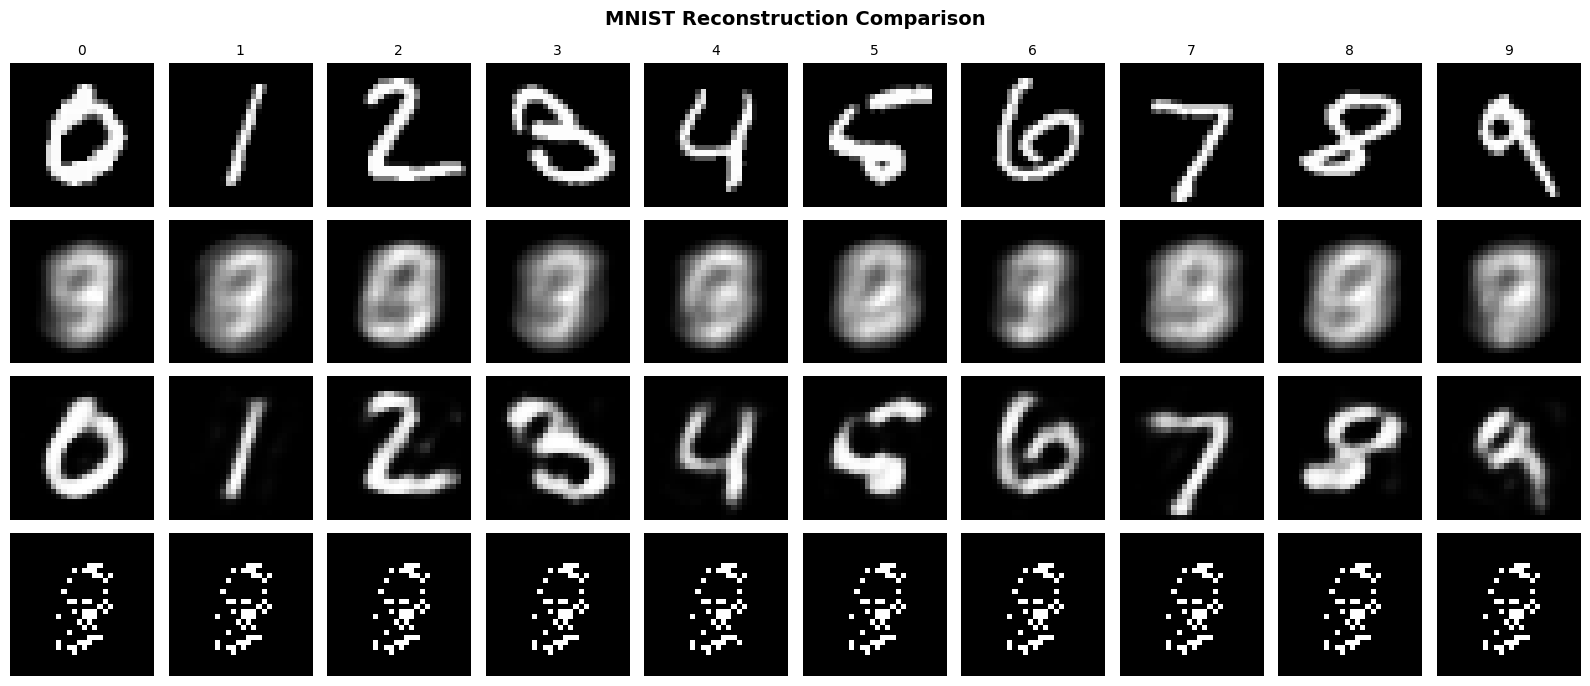

Saved: images/mnist_reconstruction.png


In [ ]:

print("Training models for reconstruction visualization...")
viz_models = {}
for arch_name, builder in architectures.items():
    np.random.seed(0)
    tf.random.set_seed(0)
    ae, enc = builder()
    ae.fit(x_train, x_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    viz_models[arch_name] = (ae, enc)
    print(f"  {arch_name} trained.")

# Pick one sample per digit
fig, axes = plt.subplots(4, 10, figsize=(16, 7))

sample_indices = [np.where(y_test == d)[0][0] for d in range(10)]
samples = x_test[sample_indices]

# Row 0: originals
for i in range(10):
    axes[0, i].imshow(samples[i, :, :, 0], cmap='gray')
    axes[0, i].set_title(str(i), fontsize=10)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10, rotation=0, labelpad=60)

# Rows 1-3: reconstructions
for row, (arch_name, (ae, enc)) in enumerate(viz_models.items(), 1):
    recons = ae.predict(samples, verbose=0)
    for i in range(10):
        axes[row, i].imshow(recons[i, :, :, 0], cmap='gray')
        axes[row, i].axis('off')
    short_name = arch_name.replace('_KSparse_Chaos', '').replace('_ReLU', '')
    axes[row, 0].set_ylabel(short_name, fontsize=10, rotation=0, labelpad=60)

plt.suptitle('MNIST Reconstruction Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/mnist_reconstruction.png', dpi=300, bbox_inches='tight')
plt.show()

# Cleanup viz models
for ae, enc in viz_models.values():
    del ae, enc
keras.backend.clear_session()
print("Saved: images/mnist_reconstruction.png")

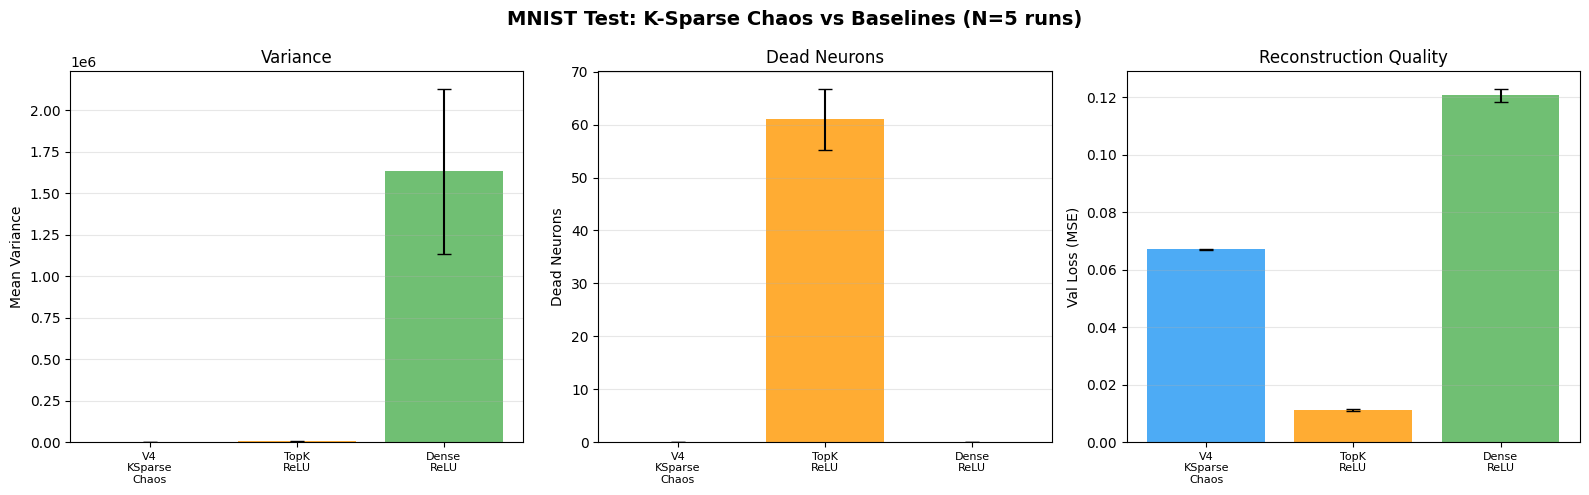

Saved: images/mnist_test.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

arch_names = list(architectures.keys())
x_pos = np.arange(len(arch_names))
colors = ['#2196F3', '#FF9800', '#4CAF50']

# Variance
means = [summary[a]['var_mean'] for a in arch_names]
stds = [summary[a]['var_std'] for a in arch_names]
axes[0].bar(x_pos, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([n.replace('_', '\n') for n in arch_names], fontsize=8)
axes[0].set_ylabel('Mean Variance')
axes[0].set_title('Variance')
axes[0].grid(True, alpha=0.3, axis='y')

# Dead neurons
dead_m = [summary[a]['dead_mean'] for a in arch_names]
dead_s = [summary[a]['dead_std'] for a in arch_names]
axes[1].bar(x_pos, dead_m, yerr=dead_s, capsize=5, color=colors, alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([n.replace('_', '\n') for n in arch_names], fontsize=8)
axes[1].set_ylabel('Dead Neurons')
axes[1].set_title('Dead Neurons')
axes[1].grid(True, alpha=0.3, axis='y')

# Val loss
loss_m = [summary[a]['loss_mean'] for a in arch_names]
loss_s = [summary[a]['loss_std'] for a in arch_names]
axes[2].bar(x_pos, loss_m, yerr=loss_s, capsize=5, color=colors, alpha=0.8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([n.replace('_', '\n') for n in arch_names], fontsize=8)
axes[2].set_ylabel('Val Loss (MSE)')
axes[2].set_title('Reconstruction Quality')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'MNIST Test: K-Sparse Chaos vs Baselines (N={NUM_RUNS} runs)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/mnist_test.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: images/mnist_test.png")

In [ ]:
save_data = {
    'experiment': 'mnist_test',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'dataset': 'MNIST',
        'train_size': len(x_train),
        'test_size': len(x_test),
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
        'latent_dim': 128,
        'k_active': 32,
    },
    'summary': {
        arch: {k: v for k, v in vals.items() if k not in ('variances', 'deads')}
        for arch, vals in summary.items()
    },
}

json_path = f'../jsons/mnist_results_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/mnist_results_20260223_225152.json
